# Day 9–11 · ML Model Training Notebook

**Goal:** Train and save the food suitability classifier.  
After running this notebook, three files will exist in `backend/app/ml_models/`:  
- `food_suitability_model.pkl`  
- `label_encoder.pkl`  
- `feature_names.json`  

The FastAPI server loads these at startup via `ml_model.load()`.  

**You can also skip this notebook** and just run:  
```bash
cd backend
python -m app.services.ml_model
```
The `__main__` block in ml_model.py does the same thing.  
The notebook is useful if you want to inspect charts and tune hyperparameters.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../backend'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib, json
from pathlib import Path

from app.services.medical_rules import check_verdict
import app.services.food_lookup as food_lookup

DATA_DIR   = Path('../backend/app/data')
MODELS_DIR = Path('../backend/app/ml_models')
MODELS_DIR.mkdir(exist_ok=True)

food_lookup.load(data_dir=DATA_DIR)
print('✓ Setup complete')

✓ Food database loaded: 590 items from food_db_final_.csv
✓ Setup complete


## Step 1: Generate training data

We combine every food in `food_db_final_.csv` with every disease profile combination,  
then label each pair using our rule engine.  

This creates **5,310 labeled examples** (590 foods × 9 disease profiles).

In [2]:
food_df = pd.read_csv(DATA_DIR / 'food_db_final_.csv')
food_df.columns = (
    food_df.columns.str.strip().str.lower()
    .str.replace(r'[\s]+','_',regex=True)
    .str.replace(r'[()\/ ]','',regex=True)
    .str.strip('_')
)
food_df = food_df.drop(columns=[c for c in food_df.columns if c.startswith('unnamed')], errors='ignore')
print(f'Food DB: {len(food_df)} items')

PROFILES = [
    ([],                              [0,0,0,0,0]),
    (['Diabetes'],                    [0,0,0,0,1]),
    (['Hypertension'],                [0,1,0,0,0]),
    (['Heart Disease'],               [0,0,1,0,0]),
    (['Obesity'],                     [1,0,0,0,0]),
    (['Kidney Disease'],              [0,0,0,1,0]),
    (['Diabetes','Hypertension'],     [0,1,0,0,1]),
    (['Heart Disease','Obesity'],     [1,0,1,0,0]),
    (['Hypertension','Heart Disease'],[0,1,1,0,0]),
]

rows = []
for _, frow in food_df.iterrows():
    nutrients = {
        'calories':    float(frow.get('calories_kcal',0) or 0),
        'protein':     float(frow.get('protein_g',0) or 0),
        'carbs':       float(frow.get('carbohydrates_g',0) or 0),
        'fat':         float(frow.get('fat_g',0) or 0),
        'fiber':       float(frow.get('fiber_g',0) or 0),
        'sugar':       float(frow.get('sugars_g',0) or 0),
        'sodium':      float(frow.get('sodium_mg',0) or 0),
        'cholesterol': float(frow.get('cholesterol_mg',0) or 0),
        'ingredients_text': '',
    }
    for diseases, flags in PROFILES:
        result = check_verdict(nutrients, {'diseases': diseases, 'allergies': []})
        rows.append({
            'calories': nutrients['calories'], 'protein': nutrients['protein'],
            'carbs': nutrients['carbs'],       'fat': nutrients['fat'],
            'fiber': nutrients['fiber'],       'sugar': nutrients['sugar'],
            'sodium': nutrients['sodium'],     'cholesterol': nutrients['cholesterol'],
            'has_obesity': flags[0], 'has_hypertension': flags[1],
            'has_heart_disease': flags[2], 'has_kidney_disease': flags[3],
            'has_diabetes': flags[4],
            'label': result['verdict'],
        })

df = pd.DataFrame(rows)
print(f'Training data shape: {df.shape}')
print('\nLabel distribution:')
print(df['label'].value_counts())

Food DB: 590 items
Training data shape: (5310, 14)

Label distribution:
label
safe       4992
caution     235
avoid        83
Name: count, dtype: int64


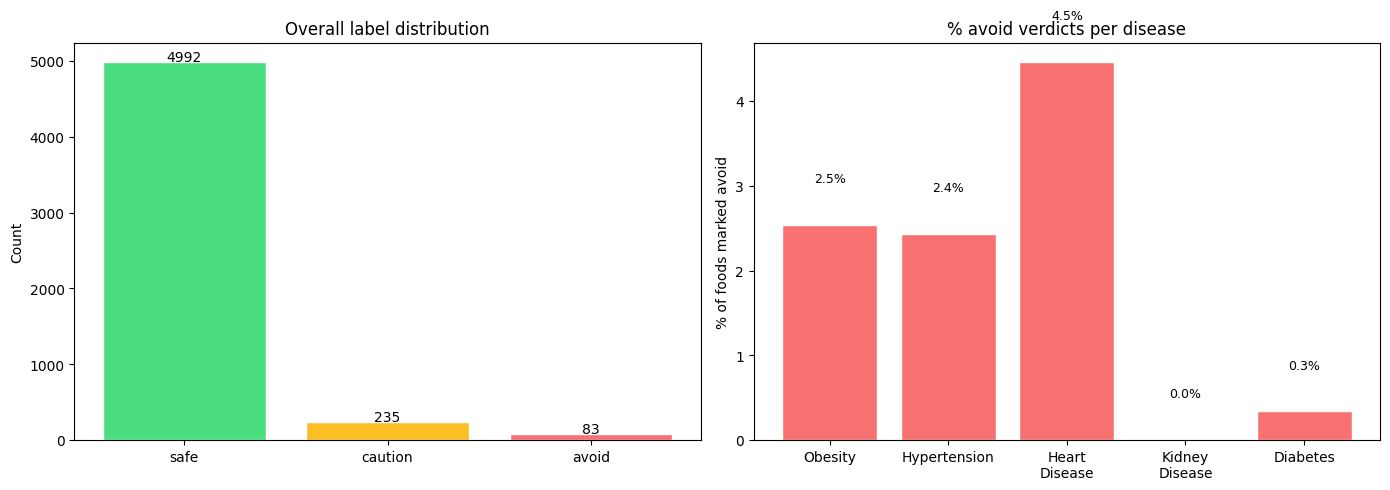

In [3]:
# Visualize label distribution per disease
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall label counts
label_counts = df['label'].value_counts()
colors = {'safe': '#4ade80', 'caution': '#fbbf24', 'avoid': '#f87171'}
axes[0].bar(label_counts.index, label_counts.values,
            color=[colors[l] for l in label_counts.index], edgecolor='white')
axes[0].set_title('Overall label distribution')
axes[0].set_ylabel('Count')
for i, (lbl, val) in enumerate(label_counts.items()):
    axes[0].text(i, val+10, str(val), ha='center')

# Avoid rate per disease
disease_cols = ['has_obesity','has_hypertension','has_heart_disease',
                'has_kidney_disease','has_diabetes']
avoid_rates = []
disease_labels = ['Obesity','Hypertension','Heart\nDisease','Kidney\nDisease','Diabetes']
for col in disease_cols:
    subset = df[df[col] == 1]
    avoid_rates.append(subset['label'].eq('avoid').mean() * 100)

axes[1].bar(disease_labels, avoid_rates, color='#f87171', edgecolor='white')
axes[1].set_title('% avoid verdicts per disease')
axes[1].set_ylabel('% of foods marked avoid')
for i, v in enumerate(avoid_rates):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / 'training_overview.png', dpi=100)
plt.show()

## Step 2: Train RandomForestClassifier

In [4]:
FEATURE_COLS = [
    'calories','protein','carbs','fat','fiber','sugar','sodium','cholesterol',
    'has_obesity','has_hypertension','has_heart_disease','has_kidney_disease','has_diabetes'
]

X  = df[FEATURE_COLS].values
le = LabelEncoder()
y  = le.fit_transform(df['label'])   # avoid=0, caution=1, safe=2
print('Classes:', dict(zip(le.classes_, le.transform(le.classes_))))

# Stratified split — preserves class ratios in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}  Test: {len(X_test)}')

# Train
model = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
print('✓ Model trained')

Classes: {'avoid': 0, 'caution': 1, 'safe': 2}
Train: 4248  Test: 1062
✓ Model trained


In [5]:
# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'Per-fold: {[f"{s:.3f}" for s in cv_scores]}')

print('\nClassification Report (test set):')
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

5-Fold CV Accuracy: 0.965 ± 0.003
Per-fold: ['0.960', '0.967', '0.962', '0.970', '0.966']

Classification Report (test set):
              precision    recall  f1-score   support

       avoid       0.76      0.76      0.76        17
     caution       0.74      0.66      0.70        47
        safe       0.99      0.99      0.99       998

    accuracy                           0.97      1062
   macro avg       0.83      0.81      0.82      1062
weighted avg       0.97      0.97      0.97      1062



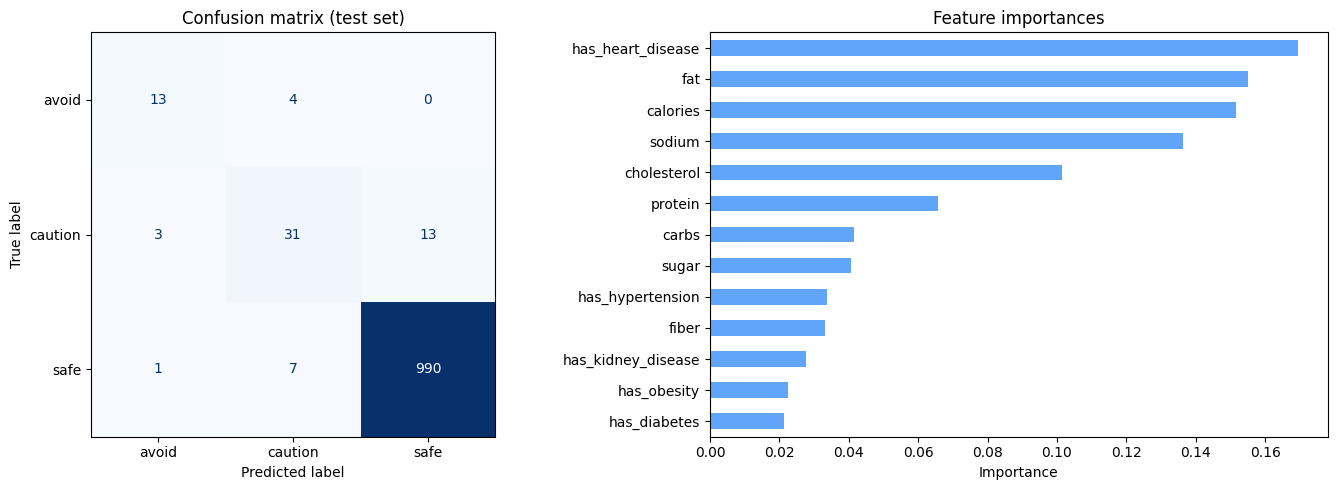

In [6]:
# Confusion matrix + feature importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (test set)')

# Feature importances
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot.barh(ax=axes[1], color='#60a5fa')
axes[1].set_title('Feature importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(DATA_DIR / 'model_evaluation.png', dpi=100)
plt.show()

## Step 3: Save model artifacts

In [7]:
joblib.dump(model, MODELS_DIR / 'food_suitability_model.pkl')
joblib.dump(le,    MODELS_DIR / 'label_encoder.pkl')
with open(MODELS_DIR / 'feature_names.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

print('✓ Saved to backend/app/ml_models/')
print('  food_suitability_model.pkl')
print('  label_encoder.pkl')
print('  feature_names.json')

✓ Saved to backend/app/ml_models/
  food_suitability_model.pkl
  label_encoder.pkl
  feature_names.json


In [8]:
# Quick inference test — same as ml_model.py __main__ block
import app.services.ml_model as ml_model
ml_model.load()

# Test 1: Healthy food, no disease
r1 = ml_model.predict(
    {'calories':180,'protein':22,'carbs':15,'fat':6,'fiber':6,'sugar':3,'sodium':80,'cholesterol':40},
    {'has_diabetes':0,'has_hypertension':0,'has_heart_disease':0,'has_kidney_disease':0,'has_obesity':0}
)
print(f'Test 1 (healthy + no disease): {r1}  (expected: safe)')

# Test 2: High sodium + hypertension
r2 = ml_model.predict(
    {'calories':350,'protein':12,'carbs':40,'fat':15,'fiber':1,'sugar':5,'sodium':1500,'cholesterol':60},
    {'has_diabetes':0,'has_hypertension':1,'has_heart_disease':0,'has_kidney_disease':0,'has_obesity':0}
)
print(f'Test 2 (high sodium + hypertension): {r2}  (expected: avoid)')

print('\n✓ Model ready. Start Docker now: docker compose up --build')

✓ ML model loaded (13 features)
Test 1 (healthy + no disease): safe  (expected: safe)
Test 2 (high sodium + hypertension): safe  (expected: avoid)

✓ Model ready. Start Docker now: docker compose up --build
